## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### Load dataset

In [4]:
df = pd.read_csv("credit_card_transcations.csv")

df.head()

,transaction_id,city,transaction_date,card_type,exp_type,gender,amount
0,1,Delhi,29-Oct-14,Gold,Bills,F,82475
1,2,Greater Mumbai,22-Aug-14,Platinum,Bills,F,32555
2,3,Bengaluru,27-Aug-14,Silver,Bills,F,101738
3,4,Greater Mumbai,12-Apr-14,Signature,Bills,F,123424
4,5,Bengaluru,5-May-15,Gold,Bills,F,171574


### Check dataset shape

In [5]:
df.shape

(26052, 7)

### Check columns

In [7]:
df.columns

Index(['transaction_id', 'city', 'transaction_date', 'card_type', 'exp_type',
       'gender', 'amount'],
      dtype='object')

In [8]:
df.describe()

,transaction_id,amount
count,26052.000000,26052.000000
mean,13026.500000,156411.537425
std,7520.708943,103063.254287
min,1.000000,1005.000000
25%,6513.750000,77120.250000
50%,13026.500000,153106.500000
75%,19539.250000,228050.000000
max,26052.000000,998077.000000


In [10]:
#### DATA PREPARATION

In [11]:
### Null values 

In [12]:
df.isnull().sum()

transaction_id      0
city                0
transaction_date    0
card_type           0
exp_type            0
gender              0
amount              0
dtype: int64

In [ ]:
### Check duplicate rows

In [13]:
df.duplicated().sum()

np.int64(0)

In [18]:
#### Convert transaction date

In [19]:
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    format="%d-%b-%y")
df.head()

,transaction_id,city,transaction_date,card_type,exp_type,gender,amount
0,1,Delhi,2014-10-29,Gold,Bills,F,82475
1,2,Greater Mumbai,2014-08-22,Platinum,Bills,F,32555
2,3,Bengaluru,2014-08-27,Silver,Bills,F,101738
3,4,Greater Mumbai,2014-04-12,Signature,Bills,F,123424
4,5,Bengaluru,2015-05-05,Gold,Bills,F,171574


In [20]:
### Check data types

In [21]:
df.dtypes

transaction_id               int64
city                        object
transaction_date    datetime64[ns]
card_type                   object
exp_type                    object
gender                      object
amount                       int64
dtype: object

In [22]:
### Create date features

In [23]:
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["month_name"] = df["transaction_date"].dt.month_name()
df["day"] = df["transaction_date"].dt.day
df["day_name"] = df["transaction_date"].dt.day_name()

In [24]:
### Check unique values

In [35]:
print("cities:", df["city"].nunique())
print("card types:", df["card_type"].nunique())
print("expense types:", df["exp_type"].nunique())
print("genders:", df["gender"].nunique())
print("years:", df["year"].nunique())


cities: 986
card types: 4
expense types: 6
genders: 2
years: 3


In [36]:
###v Card types

In [37]:
df["card_type"].value_counts()

card_type
Silver       6840
Signature    6447
Platinum     6398
Gold         6367
Name: count, dtype: int64

In [38]:
### Expense types

In [39]:
df["exp_type"].value_counts()

exp_type
Food             5463
Fuel             5257
Bills            5078
Entertainment    4762
Grocery          4754
Travel            738
Name: count, dtype: int64

In [40]:
#### Gender distribution

In [41]:
df["gender"].value_counts()

gender
F    13680
M    12372
Name: count, dtype: int64

In [42]:
#### EDA

In [ ]:
### Transaction amount distribution

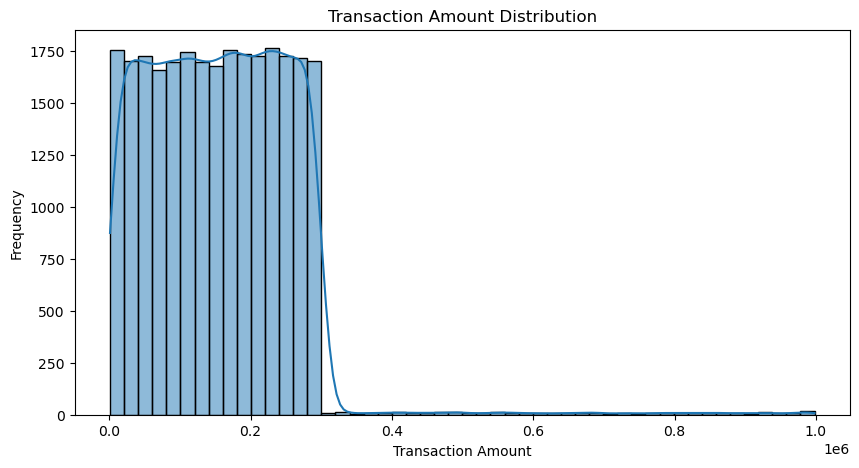

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(df["amount"], bins=50, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [44]:
#### Transactions by card type

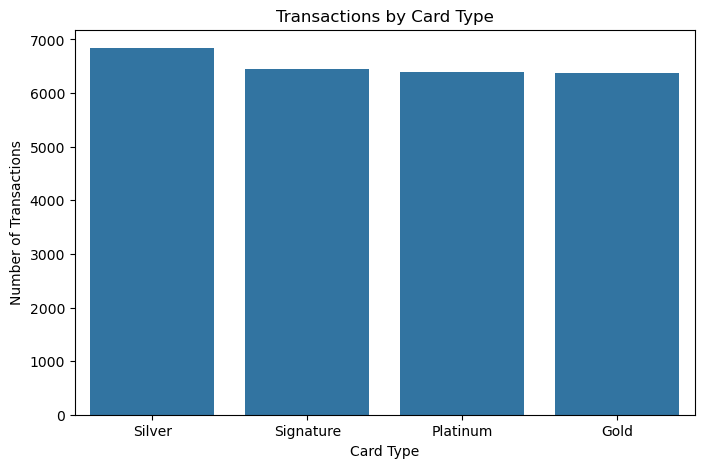

In [45]:
card_transactions = df["card_type"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=card_transactions.index,
    y=card_transactions.values
)

plt.title("Transactions by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Number of Transactions")

plt.show()

In [46]:
### Amount by card type

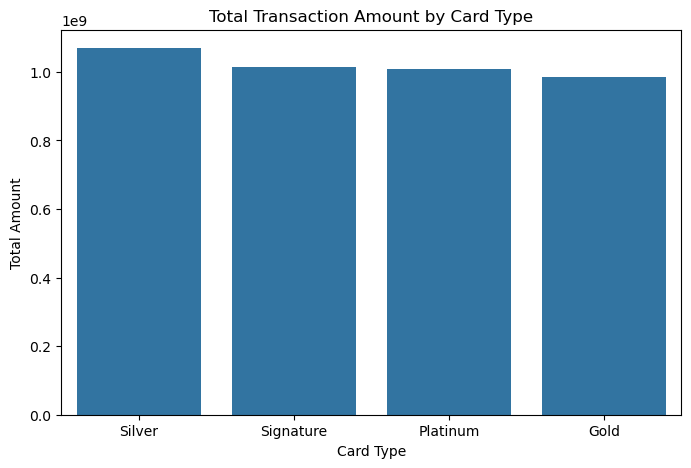

In [47]:
card_amount = (
    df.groupby("card_type")["amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=card_amount.index,
    y=card_amount.values
)

plt.title("Total Transaction Amount by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Total Amount")

plt.show()

In [48]:
### Transactions by expense type

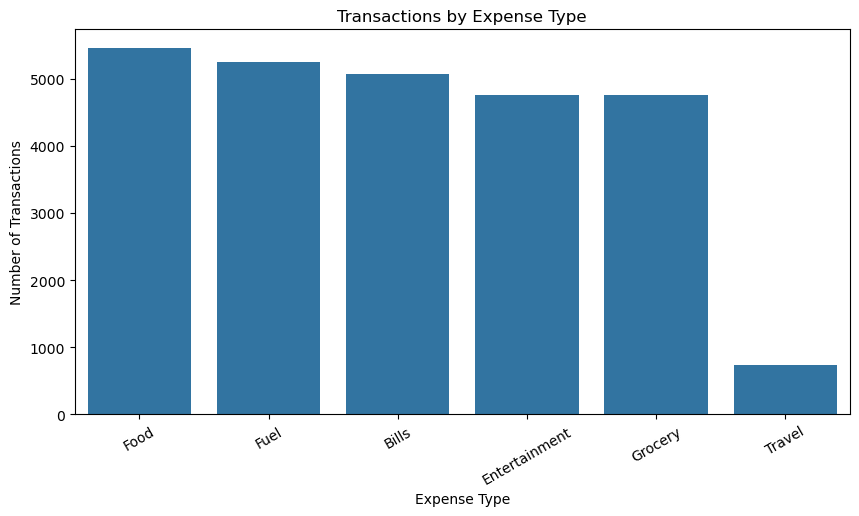

In [49]:
expense_transactions = df["exp_type"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=expense_transactions.index,
    y=expense_transactions.values
)

plt.title("Transactions by Expense Type")
plt.xlabel("Expense Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.show()

In [50]:
#### Amount by expense type

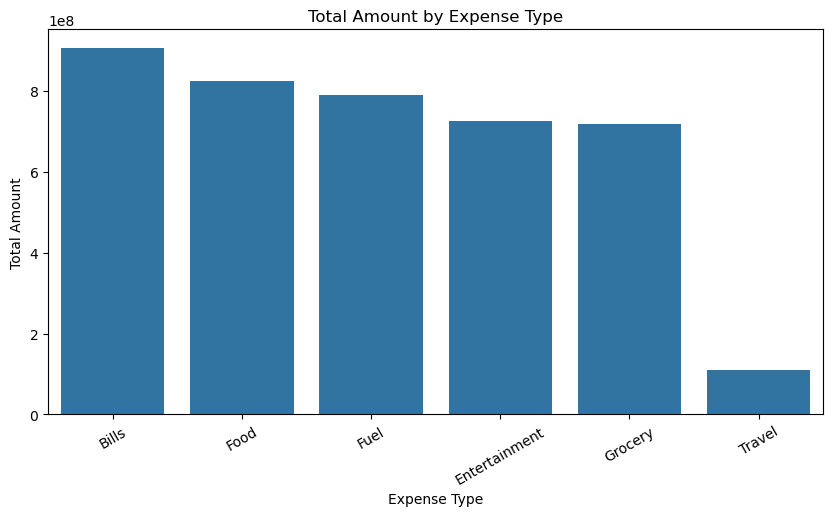

In [51]:
expense_amount = (
    df.groupby("exp_type")["amount"]
    .sum()
    .sort_values(ascending=False))
plt.figure(figsize=(10, 5))
sns.barplot(
    x=expense_amount.index,
    y=expense_amount.values)
plt.title("Total Amount by Expense Type")
plt.xlabel("Expense Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=30)
plt.show()

In [52]:
#### Gender-wise transaction analysis

In [54]:
gender_analysis = (
    df.groupby("gender")
    .agg(
        transactions=("transaction_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean")))
gender_analysis

,transactions,total_amount,average_amount
gender,,,
F,13680,2205311030,161206.946637
M,12372,1869522343,151109.145086


In [55]:
#### Gender transaction visualization

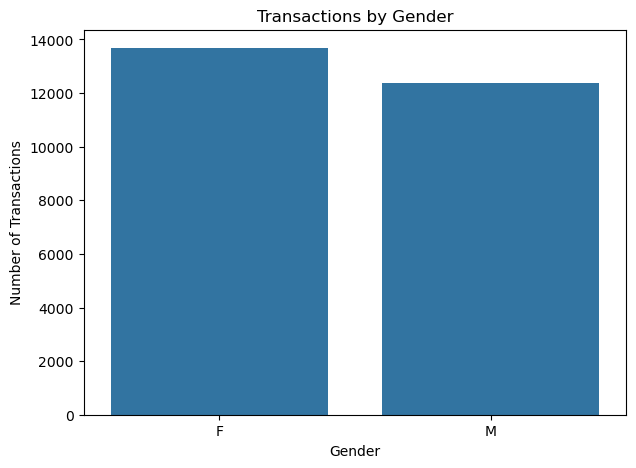

In [57]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=gender_analysis.reset_index(),
    x="gender",
    y="transactions")
plt.title("Transactions by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.show()

In [58]:
### Monthly transaction trend

In [60]:
monthly_transactions = (
    df.groupby(["year", "month"])
    .agg(
        transactions=("transaction_id", "count"),
        total_amount=("amount", "sum")).reset_index())
monthly_transactions["year_month"] = (
    monthly_transactions["year"].astype(str)
+ "-" + monthly_transactions["month"].astype(str).str.zfill(2))
monthly_transactions.head()

,year,month,transactions,total_amount,year_month
0,2013,10,1291,207360092,2013-10
1,2013,11,1257,192015963,2013-11
2,2013,12,1379,214267829,2013-12
3,2014,1,1345,207650982,2014-01
4,2014,2,1191,189220180,2014-02


In [61]:
#### Monthly transaction chart

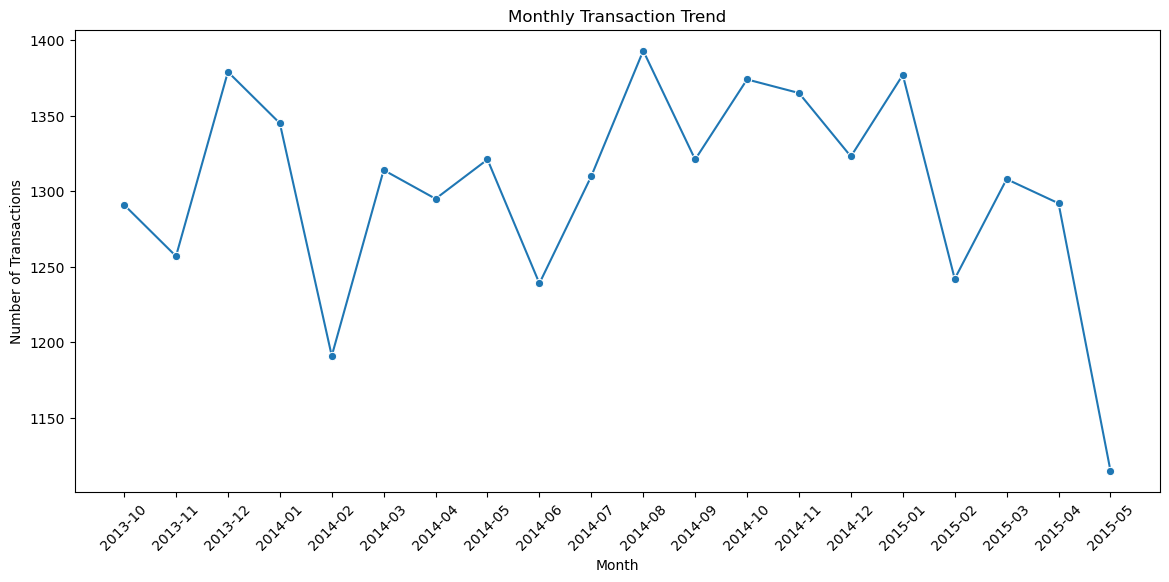

In [62]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_transactions,
    x="year_month",
    y="transactions",
    marker="o"
)

plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [63]:
#### Monthly spending trend

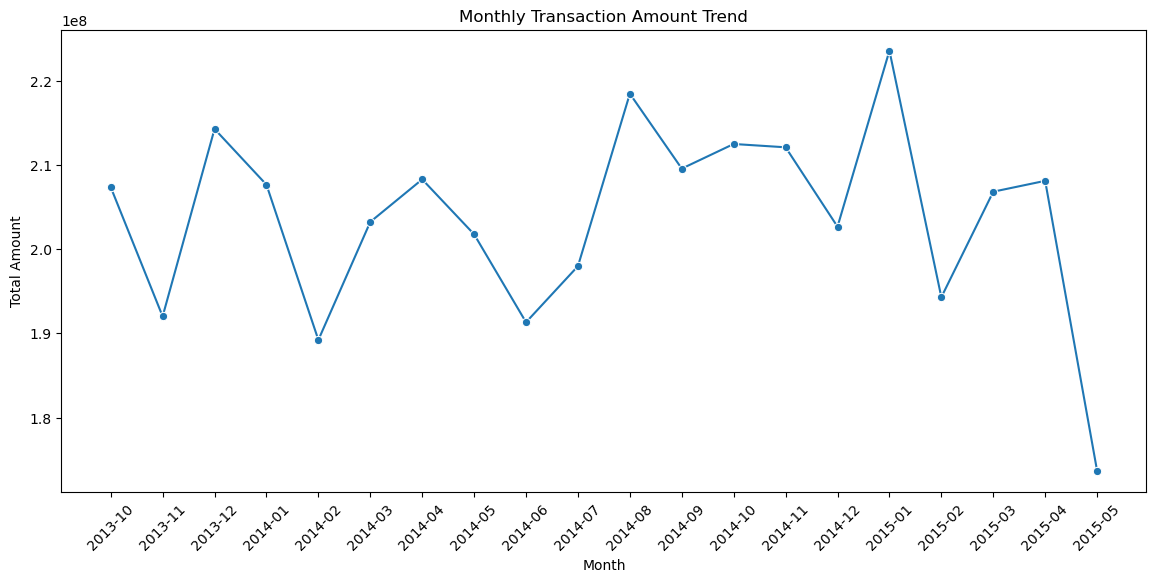

In [64]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_transactions,
    x="year_month",
    y="total_amount",
    marker="o"
)

plt.title("Monthly Transaction Amount Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")

plt.xticks(rotation=45)

plt.show()

In [65]:
####Top 10 cities by transaction amount

In [66]:
top_cities = (
    df.groupby("city")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10))
top_cities

city
Greater Mumbai    576751476
Bengaluru         572326739
Ahmedabad         567794310
Delhi             556929212
Kolkata           115466943
Lucknow           115334476
Chennai           114730600
Hyderabad         114493477
Surat             114486151
Kanpur            114370532
Name: amount, dtype: int64

In [67]:
#### Top 10 cities chart

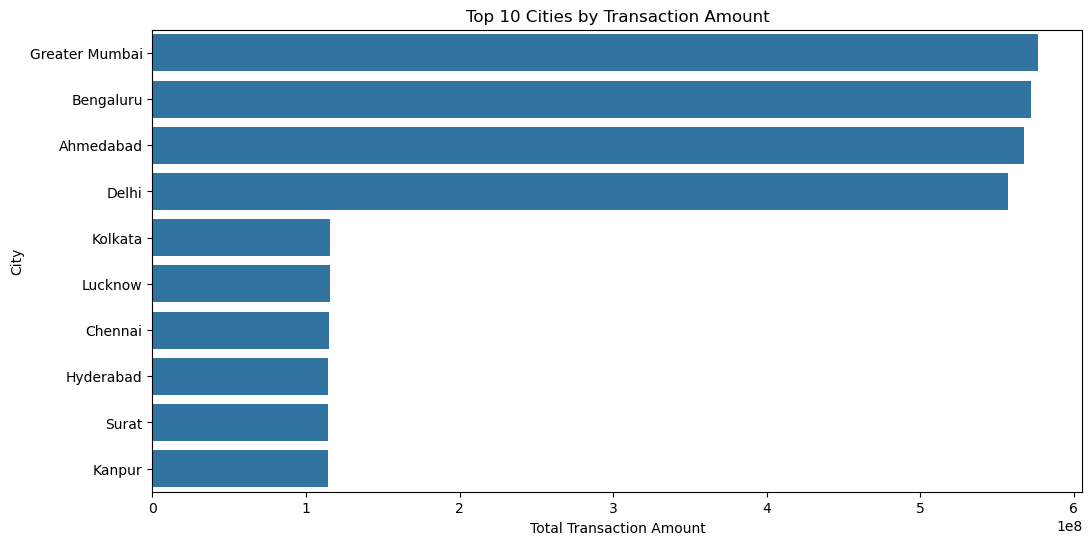

In [68]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index)
plt.title("Top 10 Cities by Transaction Amount")
plt.xlabel("Total Transaction Amount")
plt.ylabel("City")
plt.show()

In [69]:
### Top 10 cities by transaction count

In [70]:
top_cities_transactions = (
    df["city"]
    .value_counts()
    .head(10)
)

top_cities_transactions

city
Bengaluru         3552
Greater Mumbai    3493
Ahmedabad         3491
Delhi             3482
Hyderabad          784
Chennai            774
Kolkata            773
Kanpur             764
Lucknow            759
Jaipur             752
Name: count, dtype: int64

In [71]:
## Average transaction amount by card

In [72]:
avg_card_amount = (
    df.groupby("card_type")["amount"]
    .mean()
    .sort_values(ascending=False)
)

avg_card_amount

card_type
Platinum     157492.813223
Signature    157133.721886
Silver       156376.273830
Gold         154631.621800
Name: amount, dtype: float64

In [74]:
### Card type + expense type analysis

In [75]:
card_expense = pd.pivot_table(
    df,
    values="amount",
    index="card_type",
    columns="exp_type",
    aggfunc="sum"
)

card_expense

exp_type,Bills,Entertainment,Food,Fuel,Grocery,Travel
card_type,,,,,,
Gold,225533948,173468463,193756454,194343922,166246853,31189896
Platinum,222027597,185608738,210318810,194069361,171360820,24253693
Signature,226115472,178648981,206247814,187797487,186732315,27499036
Silver,233395456,188711354,214400931,212925051,193867935,26312986


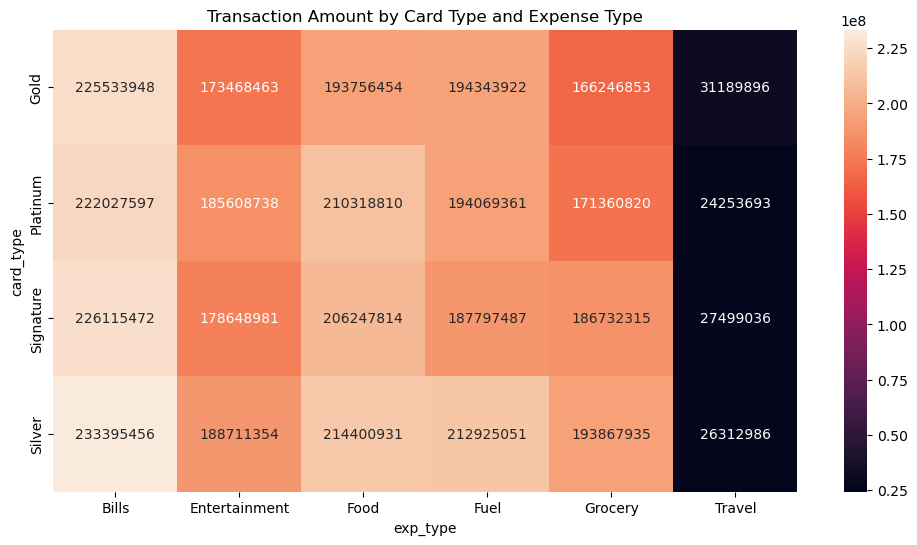

In [76]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    card_expense,
    annot=True,
    fmt=".0f"
)

plt.title("Transaction Amount by Card Type and Expense Type")

plt.show()

In [77]:
### Highest transaction

In [78]:
df.loc[df["amount"].idxmax()]

transaction_id                       81
city                     Greater Mumbai
transaction_date    2014-10-14 00:00:00
card_type                      Platinum
exp_type                          Bills
gender                                F
amount                           998077
year                               2014
month                                10
month_name                      October
day                                  14
day_name                        Tuesday
Name: 80, dtype: object

In [79]:
### Lowest transaction

In [80]:
df.loc[df["amount"].idxmin()]

transaction_id                    13445
city                              Delhi
transaction_date    2014-05-02 00:00:00
card_type                      Platinum
exp_type                        Grocery
gender                                F
amount                             1005
year                               2014
month                                 5
month_name                          May
day                                   2
day_name                         Friday
Name: 13444, dtype: object

In [81]:
### KPIs

In [82]:
total_transactions = df["transaction_id"].count()
total_amount = df["amount"].sum()
average_transaction = df["amount"].mean()
maximum_transaction = df["amount"].max()
minimum_transaction = df["amount"].min()

print("total transactions:", total_transactions)
print("total transaction amount:", total_amount)
print("average transaction amount:", round(average_transaction, 2))
print("maximum transaction:", maximum_transaction)
print("minimum transaction:", minimum_transaction)

total transactions: 26052
total transaction amount: 4074833373
average transaction amount: 156411.54
maximum transaction: 998077
minimum transaction: 1005


In [83]:
### Save cleaned dataset

In [84]:
df.to_csv(
    "credit_card_transactions_cleaned.csv",index=False)